# Fase 4 — Siamese Network con FCGR

In questa fase viene implementata una rete Siamese per confrontare coppie
di sequenze eccDNA rappresentate mediante Frequency Chaos Game
Representation (FCGR).

La rete riceve due FCGR, le processa tramite lo stesso encoder CNN
(shared weights) e produce due embedding. Gli embedding vengono
successivamente confrontati per predire se le due sequenze appartengono
alla stessa disease.

Il problema viene quindi formulato come classificazione binaria:

- `same_disease = 1`: stessa disease
- `same_disease = 0`: disease differenti

I valori di k selezionati nella fase precedente sono:

- k = 5
- k = 6
- k = 7

La prima baseline viene sviluppata utilizzando k = 5.

Per ridurre i tempi di training:
- le FCGR vengono precalcolate una sola volta per ogni sequenza;
- PyTorch utilizza CUDA quando disponibile;
- vengono utilizzati DataLoader ottimizzati;
- il training utilizza mixed precision sulla GPU.

In [266]:
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [267]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():

    print(
        "CUDA version:",
        torch.version.cuda
    )

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / (1024**3),
            2
        ),
        "GB"
    )

PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA version: 12.4
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
GPU memory: 6.0 GB


In [268]:
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [269]:
if torch.cuda.is_available():

    torch.backends.cudnn.benchmark = True

    torch.set_float32_matmul_precision(
        "high"
    )

In [270]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

SIAMESE_DIR = (
    PROCESSED_DIR
    / "siamese"
    / "final"
)

FASTA_PATH = (
    RAW_DIR
    / "eccdna_disease_detection.body.fa"
)

FCGR_CACHE_DIR = (
    PROCESSED_DIR
    / "fcgr_cache"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "siamese"
)

FCGR_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

Caricamento coppie finali

In [271]:
train_pairs = pd.read_csv(
    SIAMESE_DIR / "train_pairs.tsv",
    sep="\t",
    low_memory=False
)

val_pairs = pd.read_csv(
    SIAMESE_DIR / "val_pairs.tsv",
    sep="\t",
    low_memory=False
)

test_pairs = pd.read_csv(
    SIAMESE_DIR / "test_pairs.tsv",
    sep="\t",
    low_memory=False
)

print("Train:", train_pairs.shape)
print("Val:", val_pairs.shape)
print("Test:", test_pairs.shape)

Train: (100000, 18)
Val: (20000, 17)
Test: (20000, 17)


In [272]:
for name, df in [
    ("TRAIN", train_pairs),
    ("VAL", val_pairs),
    ("TEST", test_pairs)
]:

    print(f"\n{name}")

    print(
        df["same_disease"]
        .value_counts()
    )


TRAIN
same_disease
0    50000
1    50000
Name: count, dtype: int64

VAL
same_disease
1    10000
0    10000
Name: count, dtype: int64

TEST
same_disease
0    10000
1    10000
Name: count, dtype: int64


Calcolo id unici

In [273]:
all_ids = set()

for df in [
    train_pairs,
    val_pairs,
    test_pairs
]:

    all_ids.update(
        df["id_a"].astype(str)
    )

    all_ids.update(
        df["id_b"].astype(str)
    )

all_ids = sorted(all_ids)

print(
    "Unique sequences:",
    len(all_ids)
)

Unique sequences: 60739


## Primo esperimento k=5

In [274]:
K = 5

FCGR_SIZE = 2 ** K

print(
    "k:",
    K,
    "| FCGR:",
    FCGR_SIZE,
    "x",
    FCGR_SIZE
)

k: 5 | FCGR: 32 x 32


In [275]:
def compute_fcgr(sequence, k):

    sequence = sequence.upper()

    size = 2 ** k

    fcgr_counts = np.zeros(
        (size, size),
        dtype=np.int32
    )

    corners = {
        "A": (0.0, 1.0),
        "C": (0.0, 0.0),
        "G": (1.0, 0.0),
        "T": (1.0, 1.0)
    }

    valid_kmers = 0

    for i in range(
        len(sequence) - k + 1
    ):

        kmer = sequence[
            i:i+k
        ]

        if any(
            base not in corners
            for base in kmer
        ):
            continue

        x = 0.5
        y = 0.5

        for base in kmer:

            cx, cy = corners[base]

            x = (x + cx) * 0.5
            y = (y + cy) * 0.5

        col = min(
            int(x * size),
            size - 1
        )

        row = min(
            int(y * size),
            size - 1
        )

        fcgr_counts[
            row,
            col
        ] += 1

        valid_kmers += 1

    return fcgr_counts

In [276]:
def normalize_fcgr(fcgr):

    total = fcgr.sum()

    if total == 0:
        return fcgr.astype(
            np.float32
        )

    return (
        fcgr.astype(np.float32)
        / total
    )

Creazione indice id -> riga

In [277]:
id_to_index = {
    seq_id: idx
    for idx, seq_id
    in enumerate(all_ids)
}

len(id_to_index)

60739

In [278]:
INDEX_PATH = (
    FCGR_CACHE_DIR
    / f"id_to_index_k{K}.json"
)

FCGR_PATH = (
    FCGR_CACHE_DIR
    / f"fcgr_k{K}.npy"
)

CACHE_EXISTS = (
    INDEX_PATH.exists()
    and FCGR_PATH.exists()
)

print("FCGR cache exists:", CACHE_EXISTS)

FCGR cache exists: True


Creazione file fcgr

In [279]:
FCGR_PATH = (
    FCGR_CACHE_DIR
    / f"fcgr_k{K}.npy"
)

Recupero sequenze necessarie dal fasta

In [280]:
def load_fasta_sequences(
    fasta_path,
    target_ids
):

    target_ids = set(
        map(str, target_ids)
    )

    sequences = {}

    current_id = None
    current_sequence = []

    with open(
        fasta_path,
        "r"
    ) as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            if line.startswith(">"):

                if (
                    current_id is not None
                    and
                    current_id in target_ids
                ):

                    sequences[
                        current_id
                    ] = "".join(
                        current_sequence
                    )

                header = line[1:]

                current_id = (
                    header
                    .split("|", 1)[0]
                    .strip()
                )

                current_sequence = []

            else:

                if (
                    current_id
                    in target_ids
                ):
                    current_sequence.append(
                        line
                    )

        if (
            current_id is not None
            and
            current_id in target_ids
        ):

            sequences[
                current_id
            ] = "".join(
                current_sequence
            )

    return sequences

Precomputazione delle fcgr (una sola volta)

In [281]:
if CACHE_EXISTS:

    print(
        f"Cache k={K} già esistente."
    )

    print(
        "Le FCGR non verranno rigenerate."
    )

    with open(
        INDEX_PATH,
        "r"
    ) as f:

        id_to_index = json.load(f)

    fcgr_cache = np.load(
        FCGR_PATH,
        mmap_mode="r"
    )

    print(
        "Cache shape:",
        fcgr_cache.shape
    )

else:

    print(
        f"Cache k={K} non trovata."
    )

    print(
        "Generazione FCGR..."
    )

    # --------------------------
    # ID -> indice
    # --------------------------

    id_to_index = {
        seq_id: idx
        for idx, seq_id
        in enumerate(all_ids)
    }

    with open(
        INDEX_PATH,
        "w"
    ) as f:

        json.dump(
            id_to_index,
            f
        )

    # --------------------------
    # Caricamento FASTA
    # --------------------------

    sequences = load_fasta_sequences(
        FASTA_PATH,
        all_ids
    )

    print(
        "Requested:",
        len(all_ids)
    )

    print(
        "Loaded:",
        len(sequences)
    )

    if len(sequences) != len(all_ids):

        raise RuntimeError(
            "Non tutte le sequenze sono state trovate."
        )

    # --------------------------
    # Memory map
    # --------------------------

    fcgr_memmap = (
        np.lib.format.open_memmap(
            FCGR_PATH,
            mode="w+",
            dtype=np.float32,
            shape=(
                len(all_ids),
                FCGR_SIZE,
                FCGR_SIZE
            )
        )
    )

    # --------------------------
    # Precomputazione
    # --------------------------

    start_time = time.time()

    for i, seq_id in enumerate(
        all_ids
    ):

        sequence = sequences[
            seq_id
        ]

        counts = compute_fcgr(
            sequence,
            K
        )

        fcgr = normalize_fcgr(
            counts
        )

        fcgr_memmap[
            id_to_index[
                seq_id
            ]
        ] = fcgr

        if (
            (i + 1) % 5000 == 0
            or i == 0
        ):

            elapsed = (
                time.time()
                - start_time
            )

            print(
                f"{i+1:,}/{len(all_ids):,}"
                f" | "
                f"{elapsed/60:.1f} min"
            )

    fcgr_memmap.flush()

    del fcgr_memmap

    fcgr_cache = np.load(
        FCGR_PATH,
        mmap_mode="r"
    )

    print(
        "FCGR cache completed."
    )

    print(
        fcgr_cache.shape,
        fcgr_cache.dtype
    )

Cache k=5 già esistente.
Le FCGR non verranno rigenerate.
Cache shape: (60739, 32, 32)


In [282]:
fcgr_cache = np.load(
    FCGR_PATH,
    mmap_mode="r"
)

print(
    fcgr_cache.shape
)

print(
    fcgr_cache.dtype
)

(60739, 32, 32)
float32


Creazione dataset Pytorch

In [283]:
class SiameseFCGRDataset(
    Dataset
):

    def __init__(
        self,
        pairs,
        fcgr_path,
        id_to_index
    ):

        self.pairs = (
            pairs
            .reset_index(drop=True)
        )

        self.fcgr_path = fcgr_path

        self.id_to_index = (
            id_to_index
        )

        self.fcgr = None


    def _open_fcgr(self):

        if self.fcgr is None:

            self.fcgr = np.load(
                self.fcgr_path,
                mmap_mode="r"
            )


    def __len__(self):

        return len(
            self.pairs
        )


    def __getitem__(
        self,
        idx
    ):

        self._open_fcgr()

        row = self.pairs.iloc[idx]

        id_a = str(
            row["id_a"]
        )

        id_b = str(
            row["id_b"]
        )

        idx_a = (
            self.id_to_index[
                id_a
            ]
        )

        idx_b = (
            self.id_to_index[
                id_b
            ]
        )

        fcgr_a = np.array(
            self.fcgr[idx_a],
            dtype=np.float32,
            copy=True
        )

        fcgr_b = np.array(
            self.fcgr[idx_b],
            dtype=np.float32,
            copy=True
        )

        # aggiunge il canale:
        # H × W -> 1 × H × W

        fcgr_a = torch.from_numpy(
            fcgr_a
        ).unsqueeze(0)

        fcgr_b = torch.from_numpy(
            fcgr_b
        ).unsqueeze(0)

        label = torch.tensor(
            row["same_disease"],
            dtype=torch.float32
        )

        return (
            fcgr_a,
            fcgr_b,
            label
        )

Dataset

In [284]:
train_dataset = SiameseFCGRDataset(
    train_pairs,
    FCGR_PATH,
    id_to_index
)

val_dataset = SiameseFCGRDataset(
    val_pairs,
    FCGR_PATH,
    id_to_index
)

test_dataset = SiameseFCGRDataset(
    test_pairs,
    FCGR_PATH,
    id_to_index
)

In [285]:
a, b, y = train_dataset[0]

print(
    "A:",
    a.shape
)

print(
    "B:",
    b.shape
)

print(
    "Label:",
    y
)

A: torch.Size([1, 32, 32])
B: torch.Size([1, 32, 32])
Label: tensor(0.)


Dataloader ottimizzati per GPU

In [286]:
BATCH_SIZE = 256
NUM_WORKERS = 0

In [287]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

Encoder CNN

In [288]:
class FCGRCNNEncoder(
    nn.Module
):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.embedding = nn.Linear(
            128,
            embedding_dim
        )


    def forward(
        self,
        x
    ):

        x = self.features(x)

        x = torch.flatten(
            x,
            1
        )

        x = self.embedding(x)

        return x

In [289]:
'''class FCGRCNNEncoderV2(nn.Module):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()

        self.features = nn.Sequential(

            # 32x32 -> 32x32
            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # 32x32 -> 16x16
            nn.MaxPool2d(2),

            # 16x16 -> 16x16
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # 16x16 -> 8x8
            nn.MaxPool2d(2),

            # 8x8 -> 8x8
            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # 8x8 -> 4x4
            nn.MaxPool2d(2)
        )

        self.embedding = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 4 * 4,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                256,
                embedding_dim
            )
        )


    def forward(self, x):

        x = self.features(x)

        x = self.embedding(x)

        return x'''

'class FCGRCNNEncoderV2(nn.Module):\n\n    def __init__(\n        self,\n        embedding_dim=128\n    ):\n\n        super().__init__()\n\n        self.features = nn.Sequential(\n\n            # 32x32 -> 32x32\n            nn.Conv2d(\n                1,\n                32,\n                kernel_size=3,\n                padding=1\n            ),\n            nn.BatchNorm2d(32),\n            nn.ReLU(),\n\n            # 32x32 -> 16x16\n            nn.MaxPool2d(2),\n\n            # 16x16 -> 16x16\n            nn.Conv2d(\n                32,\n                64,\n                kernel_size=3,\n                padding=1\n            ),\n            nn.BatchNorm2d(64),\n            nn.ReLU(),\n\n            # 16x16 -> 8x8\n            nn.MaxPool2d(2),\n\n            # 8x8 -> 8x8\n            nn.Conv2d(\n                64,\n                128,\n                kernel_size=3,\n                padding=1\n            ),\n            nn.BatchNorm2d(128),\n            nn.ReLU(),\n\n         

 # Siamese Network

In [290]:
class SiameseNetwork(
    nn.Module
):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()

        self.encoder = FCGRCNNEncoder(
            embedding_dim
        )

        self.classifier = nn.Sequential(

            nn.Linear(
                embedding_dim,
                64
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                64,
                1
            )
        )


    def forward(
        self,
        x1,
        x2
    ):

        z1 = self.encoder(x1)
        z2 = self.encoder(x2)

        # distanza element-wise
        diff = torch.abs(
            z1 - z2
        )

        logits = self.classifier(
            diff
        )

        return logits.squeeze(1)

In [291]:
'''class SiameseNetworkV2(nn.Module):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()

        self.encoder = FCGRCNNEncoderV2(
            embedding_dim
        )

        self.classifier = nn.Sequential(

            nn.Linear(
                embedding_dim,
                64
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                64,
                1
            )
        )


    def forward(
        self,
        x1,
        x2
    ):

        z1 = self.encoder(x1)
        z2 = self.encoder(x2)

        diff = torch.abs(
            z1 - z2
        )

        logits = self.classifier(
            diff
        )

        return logits.squeeze(1)'''

'class SiameseNetworkV2(nn.Module):\n\n    def __init__(\n        self,\n        embedding_dim=128\n    ):\n\n        super().__init__()\n\n        self.encoder = FCGRCNNEncoderV2(\n            embedding_dim\n        )\n\n        self.classifier = nn.Sequential(\n\n            nn.Linear(\n                embedding_dim,\n                64\n            ),\n\n            nn.ReLU(),\n\n            nn.Dropout(0.4),\n\n            nn.Linear(\n                64,\n                1\n            )\n        )\n\n\n    def forward(\n        self,\n        x1,\n        x2\n    ):\n\n        z1 = self.encoder(x1)\n        z2 = self.encoder(x2)\n\n        diff = torch.abs(\n            z1 - z2\n        )\n\n        logits = self.classifier(\n            diff\n        )\n\n        return logits.squeeze(1)'

Faccio lavprare modello su gpu :)

In [292]:
model = SiameseNetwork(
    embedding_dim=128
).to(DEVICE)

print(model)

SiameseNetwork(
  (encoder): FCGRCNNEncoder(
    (features): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): AdaptiveAvgPool2d(output_size=(1, 1))
    )
    (embedding): Linear(in_features=128, out_features=128, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_

In [293]:
'''model_v2 = SiameseNetworkV2(
    embedding_dim=128
).to(DEVICE)'''

'model_v2 = SiameseNetworkV2(\n    embedding_dim=128\n).to(DEVICE)'

In [294]:
n_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"Parameters: {n_params:,}"
)

print(
    "Model device:",
    next(
        model.parameters()
    ).device
)

Parameters: 117,953
Model device: cuda:0


In [295]:
'''n_params_v2 = sum(
    p.numel()
    for p in model_v2.parameters()
)

print(
    f"Parameters V2: {n_params_v2:,}"
)

print(
    "Device:",
    next(model_v2.parameters()).device
)'''

'n_params_v2 = sum(\n    p.numel()\n    for p in model_v2.parameters()\n)\n\nprint(\n    f"Parameters V2: {n_params_v2:,}"\n)\n\nprint(\n    "Device:",\n    next(model_v2.parameters()).device\n)'

Loss e optimizer

In [296]:
criterion = (
    nn.BCEWithLogitsLoss()
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [297]:
'''criterion_v2 = nn.BCEWithLogitsLoss()

optimizer_v2 = torch.optim.AdamW(
    model_v2.parameters(),
    lr=5e-4,
    weight_decay=1e-3
)'''

'criterion_v2 = nn.BCEWithLogitsLoss()\n\noptimizer_v2 = torch.optim.AdamW(\n    model_v2.parameters(),\n    lr=5e-4,\n    weight_decay=1e-3\n)'

Mixed precision

In [298]:
USE_AMP = (
    DEVICE.type == "cuda"
)

GPU smoke test

In [299]:
batch = next(
    iter(train_loader)
)

x1, x2, y = batch

x1 = x1.to(
    DEVICE,
    non_blocking=True
)

x2 = x2.to(
    DEVICE,
    non_blocking=True
)

y = y.to(
    DEVICE,
    non_blocking=True
)

print(
    x1.shape,
    x1.device
)

print(
    x2.shape,
    x2.device
)

print(
    y.shape,
    y.device
)

torch.Size([256, 1, 32, 32]) cuda:0
torch.Size([256, 1, 32, 32]) cuda:0
torch.Size([256]) cuda:0


In [300]:
with torch.no_grad():

    logits = model(
        x1,
        x2
    )

print(
    logits.shape
)

print(
    logits[:5]
)

torch.Size([256])
tensor([0.0673, 0.0505, 0.0405, 0.0424, 0.1000], device='cuda:0')


In [301]:
'''with torch.no_grad():

    logits = model_v2(
        x1,
        x2
    )

print(
    logits.shape
)

print(
    logits[:5]
)'''

'with torch.no_grad():\n\n    logits = model_v2(\n        x1,\n        x2\n    )\n\nprint(\n    logits.shape\n)\n\nprint(\n    logits[:5]\n)'

## Mini training baseline (k = 5)

Prima di eseguire il training completo viene effettuato un breve
esperimento di 3 epoche.

Gli obiettivi sono:

- verificare che la loss diminuisca;
- verificare che il modello apprenda qualcosa rispetto al caso casuale;
- misurare il tempo per epoca;
- controllare l'utilizzo della GPU;
- verificare che training e validation funzionino correttamente.

Il modello viene addestrato utilizzando mixed precision quando CUDA
è disponibile.

In [302]:
EPOCHS = 3
LEARNING_RATE = 1e-3
RUN_MINI_TRAINING_V1 = False

In [303]:
USE_AMP = DEVICE.type == "cuda"

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

print("Mixed precision:", USE_AMP)

Mixed precision: True


In [304]:
'''scaler_v2 = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

print("Mixed precision:", USE_AMP)'''

'scaler_v2 = torch.amp.GradScaler(\n    "cuda",\n    enabled=USE_AMP\n)\n\nprint("Mixed precision:", USE_AMP)'

In [305]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device,
    use_amp=True
):
    model.train()

    running_loss = 0.0

    all_labels = []
    all_probs = []

    for x1, x2, y in loader:

        x1 = x1.to(
            device,
            non_blocking=True
        )

        x2 = x2.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            enabled=use_amp
        ):

            logits = model(
                x1,
                x2
            )

            loss = criterion(
                logits,
                y
            )

        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()

        running_loss += (
            loss.item()
            * y.size(0)
        )

        probs = torch.sigmoid(
            logits
        )

        all_labels.append(
            y.detach().cpu()
        )

        all_probs.append(
            probs.detach().cpu()
        )

    labels = torch.cat(
        all_labels
    ).numpy()

    probs = torch.cat(
        all_probs
    ).numpy()

    preds = (
        probs >= 0.5
    ).astype(int)

    epoch_loss = (
        running_loss
        / len(loader.dataset)
    )

    accuracy = accuracy_score(
        labels,
        preds
    )

    f1 = f1_score(
        labels,
        preds
    )

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "f1": f1
    }

In [306]:
@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device,
    use_amp=True
):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_probs = []

    for x1, x2, y in loader:

        x1 = x1.to(
            device,
            non_blocking=True
        )

        x2 = x2.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            enabled=use_amp
        ):

            logits = model(
                x1,
                x2
            )

            loss = criterion(
                logits,
                y
            )

        probs = torch.sigmoid(
            logits
        )

        running_loss += (
            loss.item()
            * y.size(0)
        )

        all_labels.append(
            y.cpu()
        )

        all_probs.append(
            probs.cpu()
        )

    labels = torch.cat(
        all_labels
    ).numpy()

    probs = torch.cat(
        all_probs
    ).numpy()

    preds = (
        probs >= 0.5
    ).astype(int)

    metrics = {
        "loss":
            running_loss
            / len(loader.dataset),

        "accuracy":
            accuracy_score(
                labels,
                preds
            ),

        "f1":
            f1_score(
                labels,
                preds
            ),

        "precision":
            precision_score(
                labels,
                preds,
                zero_division=0
            ),

        "recall":
            recall_score(
                labels,
                preds,
                zero_division=0
            ),

        "auroc":
            roc_auc_score(
                labels,
                probs
            )
    }

    return metrics

In [307]:
CHECKPOINT_DIR = (
    RESULTS_DIR
    / "checkpoints"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

V1_CHECKPOINT = (
    CHECKPOINT_DIR
    / f"siamese_v1_k{K}_best.pt"
)

In [308]:
if RUN_MINI_TRAINING_V1:

    history = []

    best_val_auroc = -np.inf

    for epoch in range(
        1,
        EPOCHS + 1
    ):

        start = time.time()

        train_metrics = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scaler,
            DEVICE,
            USE_AMP
        )

        val_metrics = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE,
            USE_AMP
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        elapsed = (
            time.time()
            - start
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_f1": train_metrics["f1"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_f1": val_metrics["f1"],
            "val_auroc": val_metrics["auroc"],
            "time_sec": elapsed
        })

        if val_metrics["auroc"] > best_val_auroc:

            best_val_auroc = val_metrics["auroc"]

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict":
                        model.state_dict(),
                    "optimizer_state_dict":
                        optimizer.state_dict(),
                    "val_auroc":
                        best_val_auroc,
                    "k": K
                },
                V1_CHECKPOINT
            )

            print(
                f"  -> new best checkpoint "
                f"(AUROC={best_val_auroc:.4f})"
            )

        print(
            f"Epoch {epoch:02d} | "
            f"{elapsed:.1f}s | "
            f"train loss {train_metrics['loss']:.4f} | "
            f"train F1 {train_metrics['f1']:.4f} | "
            f"val loss {val_metrics['loss']:.4f} | "
            f"val F1 {val_metrics['f1']:.4f} | "
            f"val AUROC {val_metrics['auroc']:.4f}"
        )

else:

    print(
        "Training V1 skipped."
    )

Training V1 skipped.


In [309]:
if V1_CHECKPOINT.exists():

    checkpoint = torch.load(
        V1_CHECKPOINT,
        map_location=DEVICE
    )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    print(
        "Best V1 checkpoint loaded"
    )

    print(
        "Epoch:",
        checkpoint["epoch"]
    )

    print(
        "Validation AUROC:",
        round(
            checkpoint[
                "val_auroc"
            ],
            4
        )
    )

else:

    print(
        "No V1 checkpoint found."
    )

Best V1 checkpoint loaded
Epoch: 1
Validation AUROC: 0.6023


In [310]:
'''EPOCHS_V2 = 3

history_v2 = []

for epoch in range(
    1,
    EPOCHS_V2 + 1
):

    start = time.time()

    train_metrics = train_one_epoch(
        model_v2,
        train_loader,
        criterion_v2,
        optimizer_v2,
        scaler_v2,
        DEVICE,
        USE_AMP
    )

    val_metrics = evaluate(
        model_v2,
        val_loader,
        criterion_v2,
        DEVICE,
        USE_AMP
    )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    elapsed = (
        time.time()
        - start
    )

    history_v2.append({

        "epoch": epoch,

        "train_loss":
            train_metrics["loss"],

        "train_accuracy":
            train_metrics["accuracy"],

        "train_f1":
            train_metrics["f1"],

        "val_loss":
            val_metrics["loss"],

        "val_accuracy":
            val_metrics["accuracy"],

        "val_f1":
            val_metrics["f1"],

        "val_auroc":
            val_metrics["auroc"],

        "time_sec":
            elapsed
    })

    print(
        f"Epoch {epoch:02d} | "
        f"{elapsed:.1f}s | "
        f"train loss {train_metrics['loss']:.4f} | "
        f"train F1 {train_metrics['f1']:.4f} | "
        f"val loss {val_metrics['loss']:.4f} | "
        f"val F1 {val_metrics['f1']:.4f} | "
        f"val AUROC {val_metrics['auroc']:.4f}"
    )'''

'EPOCHS_V2 = 3\n\nhistory_v2 = []\n\nfor epoch in range(\n    1,\n    EPOCHS_V2 + 1\n):\n\n    start = time.time()\n\n    train_metrics = train_one_epoch(\n        model_v2,\n        train_loader,\n        criterion_v2,\n        optimizer_v2,\n        scaler_v2,\n        DEVICE,\n        USE_AMP\n    )\n\n    val_metrics = evaluate(\n        model_v2,\n        val_loader,\n        criterion_v2,\n        DEVICE,\n        USE_AMP\n    )\n\n    if DEVICE.type == "cuda":\n        torch.cuda.synchronize()\n\n    elapsed = (\n        time.time()\n        - start\n    )\n\n    history_v2.append({\n\n        "epoch": epoch,\n\n        "train_loss":\n            train_metrics["loss"],\n\n        "train_accuracy":\n            train_metrics["accuracy"],\n\n        "train_f1":\n            train_metrics["f1"],\n\n        "val_loss":\n            val_metrics["loss"],\n\n        "val_accuracy":\n            val_metrics["accuracy"],\n\n        "val_f1":\n            val_metrics["f1"],\n\n        "va

In [311]:
if RUN_MINI_TRAINING_V1:

    history_df = pd.DataFrame(
        history
    )

    display(history_df)

else:

    print(
        "History non disponibile: "
        "training V1 non eseguito."
    )

History non disponibile: training V1 non eseguito.


In [312]:
print(
    "Checkpoint:",
    V1_CHECKPOINT
)

print(
    "Exists:",
    V1_CHECKPOINT.exists()
)

Checkpoint: ..\results\siamese\checkpoints\siamese_v1_k5_best.pt
Exists: True


In [313]:
'''history_v2_df = pd.DataFrame(
    history_v2
)

history_v2_df'''

'history_v2_df = pd.DataFrame(\n    history_v2\n)\n\nhistory_v2_df'

In [314]:
@torch.no_grad()
def evaluate_detailed(
    model,
    loader,
    criterion,
    device,
    use_amp=True
):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_probs = []

    for x1, x2, y in loader:

        x1 = x1.to(
            device,
            non_blocking=True
        )

        x2 = x2.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            enabled=use_amp
        ):

            logits = model(
                x1,
                x2
            )

            loss = criterion(
                logits,
                y
            )

        probs = torch.sigmoid(
            logits
        )

        running_loss += (
            loss.item()
            * y.size(0)
        )

        all_labels.append(
            y.cpu()
        )

        all_probs.append(
            probs.cpu()
        )

    labels = torch.cat(
        all_labels
    ).numpy()

    probs = torch.cat(
        all_probs
    ).numpy()

    preds = (
        probs >= 0.5
    ).astype(int)

    metrics = {
        "loss":
            running_loss
            / len(loader.dataset),

        "accuracy":
            accuracy_score(labels, preds),

        "f1":
            f1_score(labels, preds),

        "precision":
            precision_score(
                labels,
                preds,
                zero_division=0
            ),

        "recall":
            recall_score(
                labels,
                preds,
                zero_division=0
            ),

        "auroc":
            roc_auc_score(
                labels,
                probs
            )
    }

    return (
        metrics,
        labels,
        probs,
        preds
    )

In [315]:
val_metrics, val_labels, val_probs, val_preds = (
    evaluate_detailed(
        model,
        val_loader,
        criterion,
        DEVICE,
        USE_AMP
    )
)

val_metrics

{'loss': 0.6958156191825867,
 'accuracy': 0.5342,
 'f1': 0.6697390811117413,
 'precision': 0.5187829525483304,
 'recall': 0.9446,
 'auroc': 0.602319535}

In [316]:
print(
    "Predicted negative:",
    (val_preds == 0).sum()
)

print(
    "Predicted positive:",
    (val_preds == 1).sum()
)

print(
    "Positive prediction rate:",
    (val_preds == 1).mean()
)

Predicted negative: 1792
Predicted positive: 18208
Positive prediction rate: 0.9104


In [317]:
cm = confusion_matrix(
    val_labels,
    val_preds
)

cm

array([[1238, 8762],
       [ 554, 9446]])

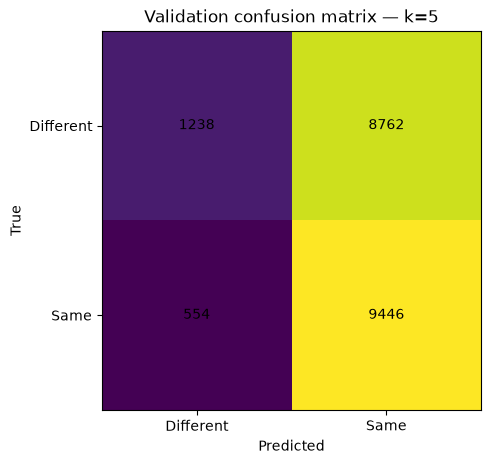

In [318]:
fig, ax = plt.subplots(
    figsize=(5, 5)
)

im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    ["Different", "Same"]
)

ax.set_yticklabels(
    ["Different", "Same"]
)

ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "True"
)

ax.set_title(
    "Validation confusion matrix — k=5"
)

for i in range(2):
    for j in range(2):

        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [319]:
print(
    classification_report(
        val_labels,
        val_preds,
        target_names=[
            "different disease",
            "same disease"
        ],
        digits=4
    )
)

                   precision    recall  f1-score   support

different disease     0.6908    0.1238    0.2100     10000
     same disease     0.5188    0.9446    0.6697     10000

         accuracy                         0.5342     20000
        macro avg     0.6048    0.5342    0.4399     20000
     weighted avg     0.6048    0.5342    0.4399     20000



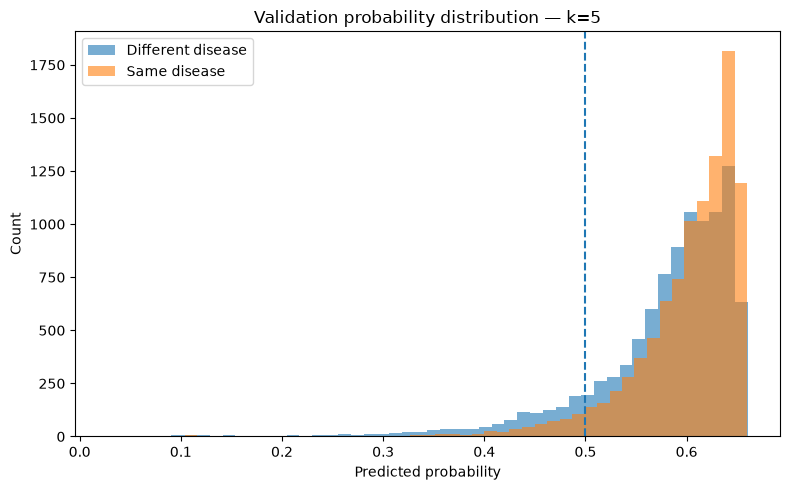

In [320]:
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    val_probs[
        val_labels == 0
    ],
    bins=50,
    alpha=0.6,
    label="Different disease"
)

plt.hist(
    val_probs[
        val_labels == 1
    ],
    bins=50,
    alpha=0.6,
    label="Same disease"
)

plt.axvline(
    0.5,
    linestyle="--"
)

plt.xlabel(
    "Predicted probability"
)

plt.ylabel(
    "Count"
)

plt.title(
    "Validation probability distribution — k=5"
)

plt.legend()

plt.tight_layout()
plt.show()

In [321]:
from sklearn.metrics.pairwise import cosine_similarity

fcgr_cache = np.load(
    FCGR_PATH,
    mmap_mode="r"
)

def compute_pair_distances(
    pairs,
    fcgr_cache,
    id_to_index
):

    results = []

    for _, row in pairs.iterrows():

        id_a = str(row["id_a"])
        id_b = str(row["id_b"])

        a = fcgr_cache[
            id_to_index[id_a]
        ].reshape(-1)

        b = fcgr_cache[
            id_to_index[id_b]
        ].reshape(-1)

        l1 = np.mean(
            np.abs(a - b)
        )

        l2 = np.sqrt(
            np.mean(
                (a - b) ** 2
            )
        )

        norm_a = np.linalg.norm(a)
        norm_b = np.linalg.norm(b)

        if norm_a > 0 and norm_b > 0:
            cosine = np.dot(a, b) / (
                norm_a * norm_b
            )
        else:
            cosine = 0.0

        results.append({
            "same_disease":
                row["same_disease"],

            "l1":
                l1,

            "l2":
                l2,

            "cosine":
                cosine
        })

    return pd.DataFrame(
        results
    )

In [322]:
distance_results_full = (
    compute_pair_distances(
        val_pairs,
        fcgr_cache,
        id_to_index
    )
)

In [323]:
distance_results_full.groupby(
    "same_disease"
)[
    ["l1", "l2", "cosine"]
].agg(
    ["mean", "median", "std"]
)

l1                            l2                      \
                  mean    median       std      mean    median       std   
same_disease                                                               
0             0.001336  0.001376  0.000338  0.002816  0.002324  0.002387   
1             0.001241  0.001263  0.000334  0.002429  0.002068  0.001949   

                cosine                      
                  mean    median       std  
same_disease                                
0             0.352223  0.325613  0.201888  
1             0.411633  0.403079  0.198058

In [324]:
baseline_cosine_auroc = roc_auc_score(
    distance_results_full["same_disease"],
    distance_results_full["cosine"]
)

baseline_l1_auroc = roc_auc_score(
    distance_results_full["same_disease"],
    -distance_results_full["l1"]
)

baseline_l2_auroc = roc_auc_score(
    distance_results_full["same_disease"],
    -distance_results_full["l2"]
)

print(f"Raw FCGR baseline — k={K}")
print(
    f"Cosine AUROC: "
    f"{baseline_cosine_auroc:.4f}"
)
print(
    f"L1 AUROC: "
    f"{baseline_l1_auroc:.4f}"
)
print(
    f"L2 AUROC: "
    f"{baseline_l2_auroc:.4f}"
)

Raw FCGR baseline — k=5
Cosine AUROC: 0.5868
L1 AUROC: 0.5819
L2 AUROC: 0.5752


## Comparison across k-mer sizes

Dopo aver validato la pipeline con k=5, vengono confrontate le
rappresentazioni FCGR ottenute con diversi valori di k.

Per ogni valore di k vengono analizzate inizialmente le prestazioni di
semplici misure di similarità tra FCGR:

- cosine similarity
- L1 distance
- L2 distance

Successivamente la Siamese Network viene addestrata utilizzando gli stessi
split e la stessa architettura, in modo da confrontare in maniera controllata
l'effetto della dimensione dei k-mer.

I valori analizzati sono:

- k = 5
- k = 6
- k = 7

In [325]:
def prepare_fcgr_cache(
    k,
    all_ids,
    fasta_path,
    cache_dir
):

    size = 2 ** k

    index_path = (
        cache_dir
        / f"id_to_index_k{k}.json"
    )

    fcgr_path = (
        cache_dir
        / f"fcgr_k{k}.npy"
    )

    cache_exists = (
        index_path.exists()
        and fcgr_path.exists()
    )

    if cache_exists:

        print(
            f"Cache k={k} già esistente."
        )

        with open(
            index_path,
            "r"
        ) as f:

            id_to_index_k = json.load(f)

        fcgr_cache_k = np.load(
            fcgr_path,
            mmap_mode="r"
        )

        print(
            "Shape:",
            fcgr_cache_k.shape
        )

        return (
            fcgr_path,
            id_to_index_k
        )

    print(
        f"Creazione cache k={k}..."
    )

    id_to_index_k = {
        seq_id: idx
        for idx, seq_id
        in enumerate(all_ids)
    }

    with open(
        index_path,
        "w"
    ) as f:

        json.dump(
            id_to_index_k,
            f
        )

    sequences = load_fasta_sequences(
        fasta_path,
        all_ids
    )

    if len(sequences) != len(all_ids):

        raise RuntimeError(
            "Non tutte le sequenze sono state trovate."
        )

    fcgr_memmap = (
        np.lib.format.open_memmap(
            fcgr_path,
            mode="w+",
            dtype=np.float32,
            shape=(
                len(all_ids),
                size,
                size
            )
        )
    )

    start = time.time()

    for i, seq_id in enumerate(
        all_ids
    ):

        counts = compute_fcgr(
            sequences[seq_id],
            k
        )

        fcgr = normalize_fcgr(
            counts
        )

        fcgr_memmap[
            id_to_index_k[
                seq_id
            ]
        ] = fcgr

        if (
            (i + 1) % 5000 == 0
            or i == 0
        ):

            elapsed = (
                time.time()
                - start
            )

            print(
                f"{i+1:,}/"
                f"{len(all_ids):,}"
                f" | "
                f"{elapsed/60:.1f} min"
            )

    fcgr_memmap.flush()

    del fcgr_memmap

    print(
        f"Cache k={k} completata."
    )

    return (
        fcgr_path,
        id_to_index_k
    )

In [326]:
FCGR_PATH_K6, id_to_index_k6 = (
    prepare_fcgr_cache(
        k=6,
        all_ids=all_ids,
        fasta_path=FASTA_PATH,
        cache_dir=FCGR_CACHE_DIR
    )
)

Creazione cache k=6...
1/60,739 | 0.0 min
5,000/60,739 | 0.2 min
10,000/60,739 | 0.4 min
15,000/60,739 | 0.6 min
20,000/60,739 | 0.8 min
25,000/60,739 | 0.9 min
30,000/60,739 | 1.9 min
35,000/60,739 | 2.1 min
40,000/60,739 | 2.1 min
45,000/60,739 | 2.2 min
50,000/60,739 | 2.3 min
55,000/60,739 | 2.5 min
60,000/60,739 | 3.6 min
Cache k=6 completata.


In [327]:
fcgr_cache_k6 = np.load(
    FCGR_PATH_K6,
    mmap_mode="r"
)

print(
    fcgr_cache_k6.shape
)

(60739, 64, 64)


In [328]:
distance_results_k6 = (
    compute_pair_distances(
        val_pairs,
        fcgr_cache_k6,
        id_to_index_k6
    )
)

In [329]:
cosine_k6 = roc_auc_score(
    distance_results_k6[
        "same_disease"
    ],
    distance_results_k6[
        "cosine"
    ]
)

l1_k6 = roc_auc_score(
    distance_results_k6[
        "same_disease"
    ],
    -distance_results_k6[
        "l1"
    ]
)

l2_k6 = roc_auc_score(
    distance_results_k6[
        "same_disease"
    ],
    -distance_results_k6[
        "l2"
    ]
)

print("Raw FCGR baseline — k=6")
print(f"Cosine AUROC: {cosine_k6:.4f}")
print(f"L1 AUROC:     {l1_k6:.4f}")
print(f"L2 AUROC:     {l2_k6:.4f}")

Raw FCGR baseline — k=6
Cosine AUROC: 0.5784
L1 AUROC:     0.5794
L2 AUROC:     0.5668


In [330]:
FCGR_PATH_K7, id_to_index_k7 = (
    prepare_fcgr_cache(
        k=7,
        all_ids=all_ids,
        fasta_path=FASTA_PATH,
        cache_dir=FCGR_CACHE_DIR
    )
)

Creazione cache k=7...
1/60,739 | 0.0 min
5,000/60,739 | 0.2 min
10,000/60,739 | 0.4 min
15,000/60,739 | 0.7 min
20,000/60,739 | 0.9 min
25,000/60,739 | 1.1 min
30,000/60,739 | 2.3 min
35,000/60,739 | 2.4 min
40,000/60,739 | 2.5 min
45,000/60,739 | 2.6 min
50,000/60,739 | 2.6 min
55,000/60,739 | 2.9 min
60,000/60,739 | 4.9 min
Cache k=7 completata.


In [331]:
fcgr_cache_k7 = np.load(
    FCGR_PATH_K7,
    mmap_mode="r"
)

print(fcgr_cache_k7.shape)

(60739, 128, 128)


In [332]:
distance_results_k7 = (
    compute_pair_distances(
        val_pairs,
        fcgr_cache_k7,
        id_to_index_k7
    )
)

In [333]:
cosine_k7 = roc_auc_score(
    distance_results_k7["same_disease"],
    distance_results_k7["cosine"]
)

l1_k7 = roc_auc_score(
    distance_results_k7["same_disease"],
    -distance_results_k7["l1"]
)

l2_k7 = roc_auc_score(
    distance_results_k7["same_disease"],
    -distance_results_k7["l2"]
)

print("Raw FCGR baseline — k=7")
print(f"Cosine AUROC: {cosine_k7:.4f}")
print(f"L1 AUROC:     {l1_k7:.4f}")
print(f"L2 AUROC:     {l2_k7:.4f}")

Raw FCGR baseline — k=7
Cosine AUROC: 0.5711
L1 AUROC:     0.5773
L2 AUROC:     0.5636


## Final training of Siamese V1 (k = 5)

Dopo il confronto tra k = 5, 6 e 7, k = 5 è stato selezionato
come valore più promettente in base alle baseline di similarità diretta.

La Siamese V1 viene quindi addestrata in modo definitivo utilizzando:

- k = 5
- checkpoint sul miglior validation AUROC
- early stopping
- mixed precision su GPU
- stesso train/validation split utilizzato negli esperimenti precedenti

L'obiettivo è individuare il miglior modello senza proseguire
l'addestramento quando la generalizzazione peggiora.

In [334]:
FINAL_MAX_EPOCHS = 20
FINAL_PATIENCE = 4
FINAL_LR = 1e-3

In [335]:
final_model = SiameseNetwork(
    embedding_dim=128
).to(DEVICE)

final_criterion = nn.BCEWithLogitsLoss()

final_optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=FINAL_LR,
    weight_decay=1e-4
)

final_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

In [336]:
FINAL_CHECKPOINT = (
    CHECKPOINT_DIR
    / f"siamese_v1_k{K}_final_best.pt"
)

In [337]:
final_history = []

best_val_auroc = -np.inf
epochs_without_improvement = 0

for epoch in range(
    1,
    FINAL_MAX_EPOCHS + 1
):

    start = time.time()

    train_metrics = train_one_epoch(
        final_model,
        train_loader,
        final_criterion,
        final_optimizer,
        final_scaler,
        DEVICE,
        USE_AMP
    )

    val_metrics = evaluate(
        final_model,
        val_loader,
        final_criterion,
        DEVICE,
        USE_AMP
    )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start

    final_history.append({
        "epoch": epoch,

        "train_loss":
            train_metrics["loss"],

        "train_accuracy":
            train_metrics["accuracy"],

        "train_f1":
            train_metrics["f1"],

        "val_loss":
            val_metrics["loss"],

        "val_accuracy":
            val_metrics["accuracy"],

        "val_f1":
            val_metrics["f1"],

        "val_auroc":
            val_metrics["auroc"],

        "time_sec":
            elapsed
    })

    print(
        f"Epoch {epoch:02d} | "
        f"{elapsed:.1f}s | "
        f"train loss {train_metrics['loss']:.4f} | "
        f"train F1 {train_metrics['f1']:.4f} | "
        f"val loss {val_metrics['loss']:.4f} | "
        f"val F1 {val_metrics['f1']:.4f} | "
        f"val AUROC {val_metrics['auroc']:.4f}"
    )

    if val_metrics["auroc"] > best_val_auroc:

        best_val_auroc = val_metrics["auroc"]

        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    final_model.state_dict(),

                "optimizer_state_dict":
                    final_optimizer.state_dict(),

                "val_auroc":
                    best_val_auroc,

                "k": K
            },
            FINAL_CHECKPOINT
        )

        print(
            f"  -> New best checkpoint "
            f"(AUROC={best_val_auroc:.4f})"
        )

    else:

        epochs_without_improvement += 1

        print(
            f"  -> No improvement "
            f"({epochs_without_improvement}/"
            f"{FINAL_PATIENCE})"
        )

    if (
        epochs_without_improvement
        >= FINAL_PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        break

Epoch 01 | 43.7s | train loss 0.6559 | train F1 0.6178 | val loss 0.7126 | val F1 0.6156 | val AUROC 0.5711
  -> New best checkpoint (AUROC=0.5711)
Epoch 02 | 19.1s | train loss 0.5788 | train F1 0.7160 | val loss 0.8441 | val F1 0.5866 | val AUROC 0.5531
  -> No improvement (1/4)
Epoch 03 | 19.0s | train loss 0.5275 | train F1 0.7560 | val loss 0.8470 | val F1 0.5944 | val AUROC 0.5374
  -> No improvement (2/4)
Epoch 04 | 19.0s | train loss 0.5017 | train F1 0.7716 | val loss 0.9200 | val F1 0.5791 | val AUROC 0.5344
  -> No improvement (3/4)
Epoch 05 | 19.0s | train loss 0.4840 | train F1 0.7823 | val loss 0.8226 | val F1 0.6307 | val AUROC 0.5579
  -> No improvement (4/4)

Early stopping triggered.


In [338]:
final_history_df = pd.DataFrame(
    final_history
)

final_history_df

,epoch,train_loss,train_accuracy,train_f1,val_loss,val_accuracy,val_f1,val_auroc,time_sec
0,1,0.655860,0.59257,0.617792,0.712583,0.54575,0.615612,0.571098,43.732574
1,2,0.578805,0.67682,0.715986,0.844080,0.52945,0.586602,0.553068,19.093449
2,3,0.527483,0.72361,0.756005,0.846955,0.52240,0.594429,0.537376,19.013026
3,4,0.501685,0.74341,0.771585,0.920034,0.52235,0.579107,0.534375,18.998900
4,5,0.484039,0.75740,0.782324,0.822618,0.52370,0.630718,0.557907,19.048672


In [339]:
checkpoint = torch.load(
    FINAL_CHECKPOINT,
    map_location=DEVICE
)

final_model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

print(
    "Best final checkpoint loaded."
)

print(
    "Best epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation AUROC:",
    round(
        checkpoint[
            "val_auroc"
        ],
        4
    )
)

Best final checkpoint loaded.
Best epoch: 1
Best validation AUROC: 0.5711


V3


In [340]:
class SiameseCosineNetwork(nn.Module):

    def __init__(
        self,
        embedding_dim=128,
        scale=10.0
    ):

        super().__init__()

        self.encoder = FCGRCNNEncoder(
            embedding_dim=embedding_dim
        )

        self.scale = scale


    def forward(
        self,
        x1,
        x2
    ):

        z1 = self.encoder(x1)
        z2 = self.encoder(x2)

        z1 = nn.functional.normalize(
            z1,
            p=2,
            dim=1
        )

        z2 = nn.functional.normalize(
            z2,
            p=2,
            dim=1
        )

        cosine = (
            z1 * z2
        ).sum(dim=1)

        logits = (
            self.scale
            * cosine
        )

        return logits

In [341]:
LR_COSINE = 1e-4

In [342]:
cosine_model = SiameseCosineNetwork(
    embedding_dim=128,
    scale=10.0
).to(DEVICE)

cosine_optimizer = torch.optim.AdamW(
    cosine_model.parameters(),
    lr=1e-4,
    weight_decay=1e-3
)

cosine_criterion = (
    nn.BCEWithLogitsLoss()
)

cosine_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

In [343]:
COSINE_EPOCHS = 5

COSINE_CHECKPOINT = (
    CHECKPOINT_DIR
    / f"siamese_v3_cosine_k{K}_best.pt"
)

cosine_history = []

best_cosine_auroc = -np.inf

for epoch in range(
    1,
    COSINE_EPOCHS + 1
):

    start = time.time()

    train_metrics = train_one_epoch(
        cosine_model,
        train_loader,
        cosine_criterion,
        cosine_optimizer,
        cosine_scaler,
        DEVICE,
        USE_AMP
    )

    val_metrics = evaluate(
        cosine_model,
        val_loader,
        cosine_criterion,
        DEVICE,
        USE_AMP
    )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start

    cosine_history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1": val_metrics["f1"],
        "val_auroc": val_metrics["auroc"],
        "time_sec": elapsed
    })

    if val_metrics["auroc"] > best_cosine_auroc:

        best_cosine_auroc = val_metrics["auroc"]

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    cosine_model.state_dict(),
                "optimizer_state_dict":
                    cosine_optimizer.state_dict(),
                "val_auroc":
                    best_cosine_auroc,
                "k": K
            },
            COSINE_CHECKPOINT
        )

        checkpoint_msg = (
            f" | new best AUROC "
            f"{best_cosine_auroc:.4f}"
        )

    else:

        checkpoint_msg = ""

    print(
        f"Epoch {epoch:02d} | "
        f"{elapsed:.1f}s | "
        f"train loss {train_metrics['loss']:.4f} | "
        f"train F1 {train_metrics['f1']:.4f} | "
        f"val loss {val_metrics['loss']:.4f} | "
        f"val F1 {val_metrics['f1']:.4f} | "
        f"val AUROC {val_metrics['auroc']:.4f}"
        f"{checkpoint_msg}"
    )

Epoch 01 | 20.1s | train loss 1.8360 | train F1 0.6265 | val loss 2.6376 | val F1 0.6664 | val AUROC 0.5994 | new best AUROC 0.5994
Epoch 02 | 20.5s | train loss 0.9788 | train F1 0.6186 | val loss 3.1425 | val F1 0.6669 | val AUROC 0.5945
Epoch 03 | 20.4s | train loss 0.8881 | train F1 0.6367 | val loss 3.1058 | val F1 0.6667 | val AUROC 0.5853
Epoch 04 | 21.3s | train loss 0.8239 | train F1 0.6480 | val loss 2.5125 | val F1 0.6657 | val AUROC 0.5924
Epoch 05 | 23.2s | train loss 0.7760 | train F1 0.6605 | val loss 3.2679 | val F1 0.6664 | val AUROC 0.5860


In [344]:
cosine_history_df = pd.DataFrame(
    cosine_history
)

cosine_history_df

,epoch,train_loss,train_accuracy,train_f1,val_loss,val_accuracy,val_f1,val_auroc,time_sec
0,1,1.835984,0.54703,0.626506,2.637624,0.50370,0.666443,0.599379,20.130122
1,2,0.978789,0.56331,0.618595,3.142531,0.50195,0.666867,0.594452,20.495067
2,3,0.888141,0.58182,0.636687,3.105828,0.50060,0.666667,0.585274,20.350656
3,4,0.823909,0.59839,0.648029,2.512462,0.50425,0.665745,0.592423,21.282082
4,5,0.775994,0.61521,0.660472,3.267950,0.50155,0.666377,0.585978,23.233236


In [345]:
cosine_checkpoint = torch.load(
    COSINE_CHECKPOINT,
    map_location=DEVICE
)

cosine_model.load_state_dict(
    cosine_checkpoint[
        "model_state_dict"
    ]
)

print(
    "Best V3 checkpoint loaded."
)

print(
    "Best epoch:",
    cosine_checkpoint["epoch"]
)

print(
    "Best validation AUROC:",
    round(
        cosine_checkpoint[
            "val_auroc"
        ],
        4
    )
)

Best V3 checkpoint loaded.
Best epoch: 1
Best validation AUROC: 0.5994
